# 06 – DistilBERT Model Fine-Tuning

**Purpose:** Train and fine-tune a `DistilBERT` sequence classifier for ticketing routing on Banking77.

This notebook demonstrates:
1. Centralized configuration lookup.
2. Fine-tuning utilizing mixed precision (AMP) and gradient accumulation.
3. Checkpoint resilience and early stopping monitoring.
4. Loading and plotting loss/accuracy learning curves from the training run.

## 0. Setup and Environment

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")

Repo root: C:\Users\gunav\Downloads\SupportAI


## 1. Execute Smoke Run Training

We execute a quick smoke run fine-tuning pipeline to check training and metrics exports on a sub-slice of samples.

In [2]:
from src.models.transformer.train import train_model

test_metrics = train_model(
    config_overlay="configs/train.yaml",
    smoke_run=False,
    resume=False
)
print("Full training complete!")
print("Final test metrics:")
print(test_metrics)

[07/13/26 20:31:00] INFO     Merging overlay configuration from:                                                   
                             C:\Users\gunav\Downloads\SupportAI\configs\train.yaml

                    INFO     Merging overlay configuration from:                                                   
                             C:\Users\gunav\Downloads\SupportAI\configs\train.yaml

                    INFO     All dataset splits cached locally under:                                              
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1. Loading...

                    INFO     Loading 'train' split from local cache:                                               
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1\train.parquet

                    INFO     Loading 'val' split from local cache:                                                 
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1\val.parquet

...

[07/13/26 20:33:50] INFO     Evaluation completed | Acc: 0.9186 | Prec (weighted): 0.9260 | Rec (weighted): 0.9186 
                             | F1 (weighted): 0.9180

                    INFO     Saving model metrics...

                    INFO     Saving JSON artifact to:                                                              
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\metrics.json

                    INFO     Final test set accuracy: 91.86%

Full training complete!
Final test metrics:
{'accuracy': 0.9185867895545314, 'precision_weighted': 0.9260351107235173, 'recall_weighted': 0.9185867895545314, 'f1_weighted': 0.9179924220192865}


## 2. Learning Curves Visualization

We load the generated `training_history.csv` file and plot the training loss vs validation loss curves.

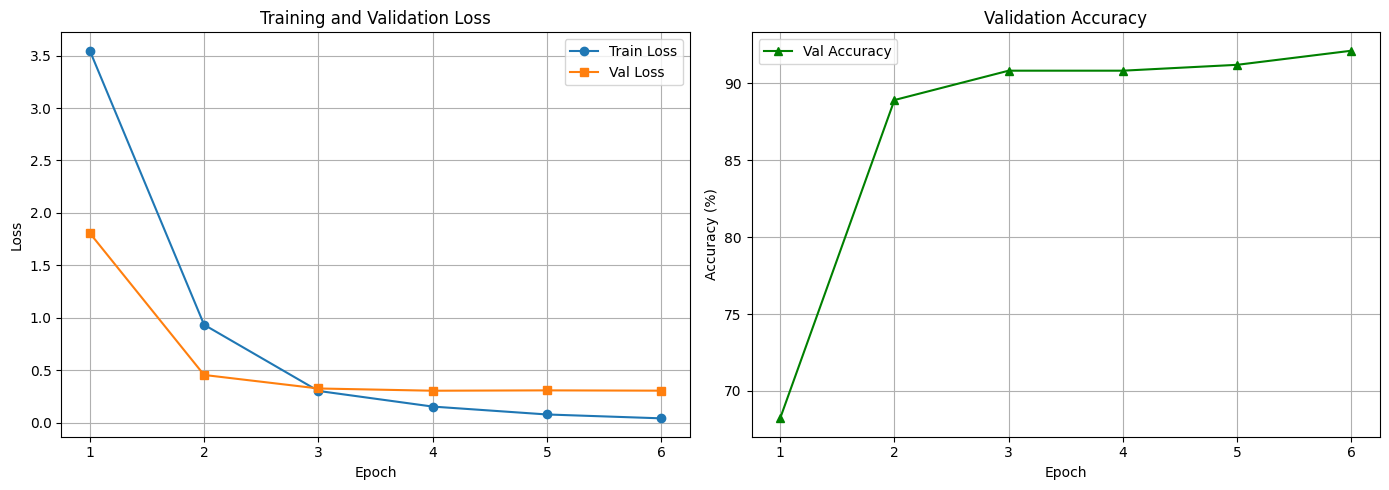

In [3]:
from src.utils.constants import OUTPUT_DIR

history_path = OUTPUT_DIR / "metrics" / "training_history.csv"
history_df = pd.read_csv(history_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Losses
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss", marker='o')
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Val Loss", marker='s')
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Plot Accuracy
axes[1].plot(history_df["epoch"], history_df["val_accuracy"] * 100, label="Val Accuracy", color='g', marker='^')
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [4]:
# Export Phase Manifest
import json

from src.api.app import get_git_commit
from src.utils.artifacts import save_yaml

training_history_path = REPO_ROOT / "outputs" / "metrics" / "training_history.json"
history = {}
if training_history_path.exists():
    with open(training_history_path) as f:
        history = json.load(f)

manifest = {
    "phase": "06_Training",
    "training_history": history,
    "git_commit": get_git_commit(),
}
save_yaml(manifest, REPO_ROOT / "outputs" / "manifests" / "phase_06_training.yaml")
print("YAML manifest saved successfully:")
print(manifest)


[07/13/26 20:33:52] INFO     Saving YAML artifact to:                                                              
                             C:\Users\gunav\Downloads\SupportAI\outputs\manifests\phase_06_training.yaml

YAML manifest saved successfully:
{'phase': '06_Training', 'training_history': [{'epoch': 1, 'train_loss': 3.5462019979406936, 'val_loss': 1.8076375286753585, 'val_accuracy': 0.6822001527883881}, {'epoch': 2, 'train_loss': 0.9342559428390013, 'val_loss': 0.45589344530570797, 'val_accuracy': 0.8892284186401833}, {'epoch': 3, 'train_loss': 0.3036716456442433, 'val_loss': 0.32708757679636885, 'val_accuracy': 0.9083269671504965}, {'epoch': 4, 'train_loss': 0.15464303599220533, 'val_loss': 0.3056414054661262, 'val_accuracy': 0.9083269671504965}, {'epoch': 5, 'train_loss': 0.07940496244561782, 'val_loss': 0.30898508356838694, 'val_accuracy': 0.9121466768525592}, {'epoch': 6, 'train_loss': 0.042435198025464645, 'val_loss': 0.306171146107883, 'val_accuracy': 0.9213139801375095}], 'git_commit': 'ef9a0498221c5c43373fcf9e951987614174868f'}
